# Fintech Capstone Project

## Day 2: Data Cleaning and SQLite Star Schema

### Tasks
1. Clean `scheme_performance.csv`
2. Validate return columns and flag anomalies
3. Validate expense ratio range
4. Create SQLite star schema tables

In [1]:
import pandas as pd
from pathlib import Path


raw_file = Path(r"E:\new download\drive-download-20260623T165027Z-3-001\07_scheme_performance.csv")

processed_folder = Path(r"E:\new download\processed")
processed_folder.mkdir(parents=True, exist_ok=True)

output_file = processed_folder / "scheme_performance_cleaned.csv"

performance = pd.read_csv(raw_file)

print("Original shape:", performance.shape)
display(performance.head())

print("\nColumn names:")
print(performance.columns.tolist())

print("\nData types:")
print(performance.dtypes)

Original shape: (40, 19)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low



Column names:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Data types:
amfi_code               int64
scheme_name               str
fund_house                str
category                  str
plan                      str
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore               int64
expense_ratio_pct     float64
morningstar_rating      int64
risk_grade                str
dtype: object


In [2]:




numeric_columns = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "benchmark_3yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "sortino_ratio",
    "std_dev_ann_pct",
    "max_drawdown_pct",
    "aum_crore",
    "expense_ratio_pct",
    "morningstar_rating"
]


for col in numeric_columns:
    performance[col] = pd.to_numeric(performance[col], errors="coerce")

print("Missing or non-numeric values in performance columns:")
print(performance[numeric_columns].isna().sum())


return_columns = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "benchmark_3yr_pct"
]

performance["return_anomaly_flag"] = False

for col in return_columns:
    performance["return_anomaly_flag"] |= (
        (performance[col] < -100) | (performance[col] > 200)
    )


performance["expense_ratio_valid"] = performance["expense_ratio_pct"].between(0.1, 2.5)


print("\nRows with suspicious return values:")
display(performance[performance["return_anomaly_flag"]][
    ["amfi_code", "scheme_name"] + return_columns
])

print("\nRows with invalid expense ratio:")
display(performance[~performance["expense_ratio_valid"]][
    ["amfi_code", "scheme_name", "expense_ratio_pct"]
])

print("\nSummary:")
print("Total rows:", len(performance))
print("Return anomaly rows:", performance["return_anomaly_flag"].sum())
print("Invalid expense ratio rows:", (~performance["expense_ratio_valid"]).sum())

Missing or non-numeric values in performance columns:
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
dtype: int64

Rows with suspicious return values:


,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct



Rows with invalid expense ratio:


,amfi_code,scheme_name,expense_ratio_pct



Summary:
Total rows: 40
Return anomaly rows: 0
Invalid expense ratio rows: 0


In [3]:

duplicates_removed = performance.duplicated().sum()
performance = performance.drop_duplicates()


performance = performance.sort_values(
    by=["amfi_code", "scheme_name"]
).reset_index(drop=True)

performance.to_csv(output_file, index=False)

print("Duplicate rows removed:", duplicates_removed)
print("Final cleaned shape:", performance.shape)
print("Saved cleaned file here:", output_file)

display(performance.head())

Duplicate rows removed: 0
Final cleaned shape: (40, 21)
Saved cleaned file here: E:\new download\processed\scheme_performance_cleaned.csv


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_anomaly_flag,expense_ratio_valid
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,True
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,False,True
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,0.87,1.44,19.0,-13.67,23185,1.38,5,High,False,True
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,Regular,14.82,13.78,12.86,12.44,1.34,...,0.98,1.25,14.0,-15.07,23500,1.60,5,Moderate,False,True
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High,False,True


## Day 2 Result: Scheme Performance Cleaning

- Loaded 40 scheme performance records.
- Converted all return and performance columns to numeric format.
- Checked return values for anomalies below -100% and above 200%.
- No return anomalies were found.
- Validated expense ratios against the 0.1%–2.5% range.
- All expense ratios were valid.
- Saved the cleaned dataset as `scheme_performance_cleaned.csv`.

In [4]:


from pathlib import Path

processed_folder = Path(r"E:\new download\processed")
processed_folder.mkdir(parents=True, exist_ok=True)

output_file = processed_folder / "scheme_performance_cleaned.csv"

performance.to_csv(output_file, index=False)

print("Cleaned scheme performance file saved here:")
print(output_file)

Cleaned scheme performance file saved here:
E:\new download\processed\scheme_performance_cleaned.csv


## SQLite Star Schema Design

Created SQLite star schema in:

`sql/day2_star_schema.sql`

Tables created:
- dim_fund
- dim_date
- fact_nav
- fact_transactions
- fact_performance
- fact_aum

Primary keys, foreign keys, validation checks, unique constraints, and indexes have been defined.

## Load Cleaned Datasets into SQLite

This section loads cleaned CSV datasets into a SQLite database using SQLAlchemy and verifies that database row counts match the source CSV files.

In [8]:
%pip install sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- -----------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
from pathlib import Path
from sqlalchemy import create_engine, text


processed_folder = Path(r"E:\new download\processed")


db_path = Path(r"D:\fintech-capstone-project\data\fintech_capstone.db")


db_path.parent.mkdir(parents=True, exist_ok=True)


engine = create_engine(f"sqlite:///{db_path}")


nav_df = pd.read_csv(processed_folder / "nav_history_cleaned_daily.csv")
transactions_df = pd.read_csv(processed_folder / "investor_transactions_cleaned.csv")
performance_df = pd.read_csv(processed_folder / "scheme_performance_cleaned.csv")

nav_df.to_sql("nav_history", engine, if_exists="replace", index=False)
transactions_df.to_sql("investor_transactions", engine, if_exists="replace", index=False)
performance_df.to_sql("scheme_performance", engine, if_exists="replace", index=False)

print("Cleaned datasets loaded into SQLite successfully.")
print(f"Database saved at: {db_path}")

Cleaned datasets loaded into SQLite successfully.
Database saved at: D:\fintech-capstone-project\data\fintech_capstone.db


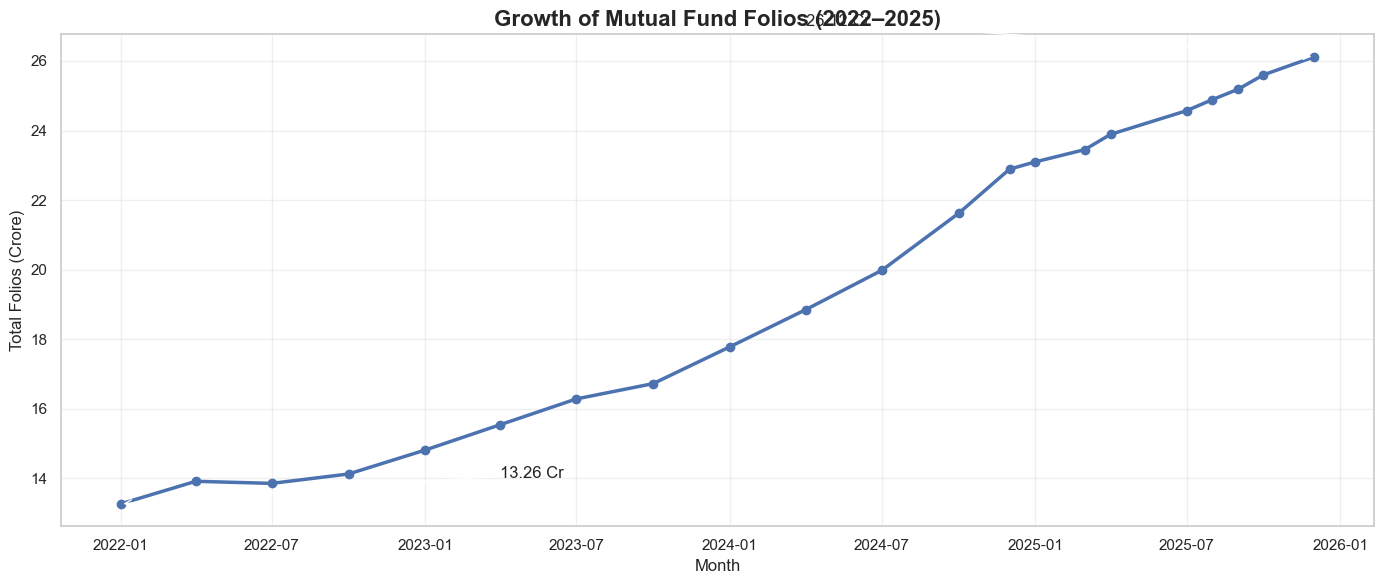

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2.5
)

plt.title("Growth of Mutual Fund Folios (2022–2025)", fontsize=16, weight="bold")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(alpha=0.3)

# January 2022
plt.annotate(
    "13.26 Cr",
    xy=(folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"]),
    xytext=(folio.iloc[5]["month"], 14),
    arrowprops=dict(arrowstyle="->")
)

# December 2025
plt.annotate(
    "26.12 Cr",
    xy=(folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"]),
    xytext=(folio.iloc[-12]["month"], 27),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()

plt.savefig(
    "../images/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [2]:

source_counts = {
    "nav_history": len(nav_df),
    "investor_transactions": len(transactions_df),
    "scheme_performance": len(performance_df)
}

with engine.connect() as connection:
    db_counts = {
        "nav_history": connection.execute(
            text("SELECT COUNT(*) FROM nav_history")
        ).scalar(),

        "investor_transactions": connection.execute(
            text("SELECT COUNT(*) FROM investor_transactions")
        ).scalar(),

        "scheme_performance": connection.execute(
            text("SELECT COUNT(*) FROM scheme_performance")
        ).scalar()
    }


verification = pd.DataFrame({
    "table_name": source_counts.keys(),
    "source_csv_rows": source_counts.values(),
    "sqlite_rows": db_counts.values()
})

verification["match"] = (
    verification["source_csv_rows"] == verification["sqlite_rows"]
)

display(verification)

if verification["match"].all():
    print("SUCCESS: All SQLite row counts match the cleaned source CSV files.")
else:
    print("WARNING: Some row counts do not match.")

,table_name,source_csv_rows,sqlite_rows,match
0,nav_history,64320,64320,True
1,investor_transactions,32778,32778,True
2,scheme_performance,40,40,True


SUCCESS: All SQLite row counts match the cleaned source CSV files.


## Analytical SQL Queries

The following section runs analytical SQL queries against the SQLite database.

In [3]:
# Query 1: Top 5 funds by AUM
query_1 = """
SELECT
    scheme_name,
    fund_house,
    category,
    aum_crore
FROM scheme_performance
ORDER BY aum_crore DESC
LIMIT 5;
"""

top_5_funds_by_aum = pd.read_sql(query_1, engine)
display(top_5_funds_by_aum)

,scheme_name,fund_house,category,aum_crore
0,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,49046
1,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,47469
2,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,43630
3,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,Large Cap,41828
4,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap,41728


In [4]:
queries = {
    "1. Top 5 funds by AUM": """
        SELECT scheme_name, fund_house, category, aum_crore
        FROM scheme_performance
        ORDER BY aum_crore DESC
        LIMIT 5;
    """,

    "2. Average NAV per month": """
        SELECT substr(date, 1, 7) AS month,
               ROUND(AVG(nav), 4) AS average_nav
        FROM nav_history
        GROUP BY substr(date, 1, 7)
        ORDER BY month;
    """,

    "3. SIP year-over-year growth": """
        SELECT
            substr(transaction_date, 1, 4) AS year,
            SUM(amount_inr) AS sip_amount,
            ROUND(
                (
                    SUM(amount_inr) -
                    LAG(SUM(amount_inr)) OVER (
                        ORDER BY substr(transaction_date, 1, 4)
                    )
                ) * 100.0 /
                LAG(SUM(amount_inr)) OVER (
                    ORDER BY substr(transaction_date, 1, 4)
                ),
                2
            ) AS sip_yoy_growth_pct
        FROM investor_transactions
        WHERE transaction_type = 'SIP'
        GROUP BY substr(transaction_date, 1, 4)
        ORDER BY year;
    """,

    "4. Transactions by state": """
        SELECT state,
               COUNT(*) AS transaction_count,
               ROUND(SUM(amount_inr), 2) AS total_transaction_amount
        FROM investor_transactions
        GROUP BY state
        ORDER BY total_transaction_amount DESC;
    """,

    "5. Funds with expense ratio below 1%": """
        SELECT scheme_name, fund_house, category, plan, expense_ratio_pct
        FROM scheme_performance
        WHERE expense_ratio_pct < 1
        ORDER BY expense_ratio_pct ASC;
    """,

    "6. Top 10 investors by total investment": """
        SELECT investor_id,
               ROUND(SUM(amount_inr), 2) AS total_investment_amount
        FROM investor_transactions
        WHERE transaction_type IN ('SIP', 'Lumpsum')
        GROUP BY investor_id
        ORDER BY total_investment_amount DESC
        LIMIT 10;
    """,

    "7. Transactions by payment mode": """
        SELECT payment_mode,
               COUNT(*) AS transaction_count,
               ROUND(SUM(amount_inr), 2) AS total_transaction_amount
        FROM investor_transactions
        GROUP BY payment_mode
        ORDER BY total_transaction_amount DESC;
    """,

    "8. Category-wise average returns and AUM": """
        SELECT category,
               ROUND(AVG(return_1yr_pct), 2) AS avg_return_1yr_pct,
               ROUND(AVG(return_3yr_pct), 2) AS avg_return_3yr_pct,
               ROUND(AVG(aum_crore), 2) AS avg_aum_crore
        FROM scheme_performance
        GROUP BY category
        ORDER BY avg_return_3yr_pct DESC;
    """,

    "9. Top 10 funds by Sharpe ratio": """
        SELECT scheme_name,
               category,
               sharpe_ratio,
               return_3yr_pct,
               std_dev_ann_pct
        FROM scheme_performance
        ORDER BY sharpe_ratio DESC
        LIMIT 10;
    """,

    "10. Monthly investments versus redemptions": """
        SELECT
            substr(transaction_date, 1, 7) AS month,
            ROUND(SUM(
                CASE
                    WHEN transaction_type IN ('SIP', 'Lumpsum')
                    THEN amount_inr
                    ELSE 0
                END
            ), 2) AS investment_amount,
            ROUND(SUM(
                CASE
                    WHEN transaction_type = 'Redemption'
                    THEN amount_inr
                    ELSE 0
                END
            ), 2) AS redemption_amount
        FROM investor_transactions
        GROUP BY substr(transaction_date, 1, 7)
        ORDER BY month;
    """
}

for title, sql_query in queries.items():
    print(f"\n{'=' * 70}\n{title}\n{'=' * 70}")
    result = pd.read_sql(sql_query, engine)
    display(result)


1. Top 5 funds by AUM


,scheme_name,fund_house,category,aum_crore
0,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,49046
1,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,47469
2,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,43630
3,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,Large Cap,41828
4,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap,41728



2. Average NAV per month


,month,average_nav
0,2022-01,207.0465
1,2022-02,207.7225
2,2022-03,209.6916
3,2022-04,211.7939
4,2022-05,212.7343
5,2022-06,213.8567
6,2022-07,213.9494
7,2022-08,215.6953
8,2022-09,218.4737
9,2022-10,219.5285



3. SIP year-over-year growth


...

,category,avg_return_1yr_pct,avg_return_3yr_pct,avg_aum_crore
0,Small Cap,22.26,21.69,32872.00
1,Mid Cap,15.98,16.59,28426.29
2,Flexi Cap,16.59,15.50,26462.00
3,Value,16.67,14.76,2571.00
4,Large & Mid Cap,14.91,14.56,49046.00
5,ELSS,11.16,13.58,2989.00
6,Large Cap,13.72,12.99,23176.14
7,Index,13.76,12.10,7350.00
8,Index/ETF,10.14,11.77,20284.00
9,Short Duration,6.83,7.37,27953.00



9. Top 10 funds by Sharpe ratio


,scheme_name,category,sharpe_ratio,return_3yr_pct,std_dev_ann_pct
0,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,7.68,0.5
1,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,6.18,0.5
2,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,5.14,0.5
3,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,1.84,7.37,4.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,1.52,6.07,4.0
5,Nippon India Gilt Securities Fund - Regular - ...,Gilt,1.33,5.31,4.0
6,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,1.06,14.84,14.0
7,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,1.06,14.81,14.0
8,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,1.03,14.41,14.0
9,Nippon India Large Cap Fund - Regular - Growth,Large Cap,1.00,14.00,14.0



10. Monthly investments versus redemptions


,month,investment_amount,redemption_amount
0,2024-01,138145180.0,79503125.0
1,2024-02,124017427.0,69871989.0
2,2024-03,136898526.0,76554972.0
3,2024-04,141057984.0,67445890.0
4,2024-05,127888504.0,77237848.0
5,2024-06,138116717.0,84148612.0
6,2024-07,130656359.0,67075667.0
7,2024-08,146567929.0,81237196.0
8,2024-09,126063882.0,62497934.0
9,2024-10,139716075.0,73935279.0


# Clean Remaining Day 2 Datasets

This section performs basic cleaning for the remaining mutual fund datasets:
- remove duplicates
- standardise column names
- trim text fields
- parse date columns
- validate numeric values
- save cleaned files in data/processed

In [1]:
import pandas as pd
from pathlib import Path

raw_folder = Path(r"D:\fintech-capstone-project\data\raw")
processed_folder = Path(r"D:\fintech-capstone-project\data\processed")

processed_folder.mkdir(parents=True, exist_ok=True)

def basic_clean(df):
    
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )

    
    df = df.drop_duplicates()

    
    text_cols = df.select_dtypes(include="object").columns

    for col in text_cols:
        df[col] = df[col].astype(str).str.strip()

    return df


datasets = {
    "01_fund_master.csv": "fund_master_cleaned.csv",
    "03_aum_by_fund_house.csv": "aum_by_fund_house_cleaned.csv",
    "04_monthly_sip_inflows.csv": "monthly_sip_inflows_cleaned.csv",
    "05_category_inflows.csv": "category_inflows_cleaned.csv",
    "06_industry_folio_count.csv": "industry_folio_count_cleaned.csv",
    "09_portfolio_holdings.csv": "portfolio_holdings_cleaned.csv",
    "10_benchmark_indices.csv": "benchmark_indices_cleaned.csv"
}

summary = []

for raw_file, cleaned_file in datasets.items():
    file_path = raw_folder / raw_file

    if file_path.exists():
        df = pd.read_csv(file_path)

        original_rows = len(df)

        df = basic_clean(df)

        for col in df.columns:
            if "date" in col or "month" in col:
                try:
                    df[col] = pd.to_datetime(df[col], errors="ignore")
                except Exception:
                    pass

        
        output_path = processed_folder / cleaned_file
        df.to_csv(output_path, index=False)

        summary.append({
            "raw_file": raw_file,
            "cleaned_file": cleaned_file,
            "original_rows": original_rows,
            "cleaned_rows": len(df),
            "saved": True
        })

    else:
        summary.append({
            "raw_file": raw_file,
            "cleaned_file": cleaned_file,
            "original_rows": "File not found",
            "cleaned_rows": "-",
            "saved": False
        })

summary_df = pd.DataFrame(summary)

print("Remaining datasets cleaned successfully.")
display(summary_df)

C:\Users\HP\AppData\Local\Temp\ipykernel_22064\896920421.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns
C:\Users\HP\AppData\Local\Temp\ipykernel_22064\896920421.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migrat

Remaining datasets cleaned successfully.


,raw_file,cleaned_file,original_rows,cleaned_rows,saved
0,01_fund_master.csv,fund_master_cleaned.csv,40,40,True
1,03_aum_by_fund_house.csv,aum_by_fund_house_cleaned.csv,90,90,True
2,04_monthly_sip_inflows.csv,monthly_sip_inflows_cleaned.csv,48,48,True
3,05_category_inflows.csv,category_inflows_cleaned.csv,144,144,True
4,06_industry_folio_count.csv,industry_folio_count_cleaned.csv,21,21,True
5,09_portfolio_holdings.csv,portfolio_holdings_cleaned.csv,322,322,True
6,10_benchmark_indices.csv,benchmark_indices_cleaned.csv,8050,8050,True


In [1]:
import os
print(os.listdir("../data/processed"))

['.gitkeep', '.gitkeepp', 'aum_by_fund_house_cleaned.csv', 'benchmark_indices_cleaned.csv', 'category_inflows_cleaned.csv', 'fund_master_cleaned.csv', 'industry_folio_count_cleaned.csv', 'investor_transactions_cleaned.csv', 'monthly_sip_inflows_cleaned.csv', 'nav_history_cleaned.csv', 'portfolio_holdings_cleaned.csv', 'scheme_performance_cleaned.csv']


In [2]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

print(nav.shape)
print(nav["date"].isna().sum())
print(nav["amfi_code"].nunique())

(64320, 3)
0
40


In [3]:
print(nav.shape)
print(nav["date"].isna().sum())

(64320, 3)
0


In [4]:
print(nav["amfi_code"].nunique())
print(nav["date"].min())
print(nav["date"].max())

40
2022-01-03
2026-05-29


In [5]:
nav_df = pd.read_csv(processed_folder / "nav_history_cleaned.csv")

nav_df.to_sql("nav_history", engine, if_exists="replace", index=False)

NameError: name 'processed_folder' is not defined

In [6]:
import pandas as pd
from pathlib import Path
from sqlalchemy import create_engine

# Folder containing cleaned CSVs
processed_folder = Path(r"D:\fintech-capstone-project\data\processed")

# SQLite database path
db_path = Path(r"D:\fintech-capstone-project\data\fintech_capstone.db")

# Create engine
engine = create_engine(f"sqlite:///{db_path}")

# Load cleaned datasets
nav_df = pd.read_csv(processed_folder / "nav_history_cleaned.csv")
transactions_df = pd.read_csv(processed_folder / "investor_transactions_cleaned.csv")
performance_df = pd.read_csv(processed_folder / "scheme_performance_cleaned.csv")

# Write to SQLite
nav_df.to_sql("nav_history", engine, if_exists="replace", index=False)
transactions_df.to_sql("investor_transactions", engine, if_exists="replace", index=False)
performance_df.to_sql("scheme_performance", engine, if_exists="replace", index=False)

print("SQLite database updated successfully!")
print(nav_df.shape)
print(nav_df["date"].isna().sum())

SQLite database updated successfully!
(64320, 3)
0
